# Estudio de caso XAI — Sitios de anidación de la tórtola senegalesa
**Asignatura:** Explicar no es entender: IA explicativa y sus límites causales | **Universidad Santo Tomás**  
**Datos:** Banisaffar & Alizadeh Shabani (2024). Dryad. https://doi.org/10.5061/dryad.gxd2547rk

**Enlace reproducible (repositorio del estudiante):** https://github.com/lauradanielamedinapa/Proyecto-IA-Clasificador-de-flores/tree/main/IA-Explicativa-Tortola

## Fase 0 — Instalación y librerías

In [1]:
%pip install -q shap lime PyALE openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import io, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42

# Paleta vibrante
ROSA='#E91E8C'; VIOLETA='#7C3AED'; AZUL='#0EA5E9'
VERDE='#10B981'; NARANJA='#F59E0B'; ROJO='#EF4444'; MORADO='#8B5CF6'
PALETTE=[ROSA,VIOLETA,AZUL,VERDE,NARANJA,ROJO,MORADO]
POS_COLOR=ROSA; NEG_COLOR=AZUL

plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False})
print('Listo')

Listo


## Fase 1 — Datos

96 sitios urbanos de Karaj, Irán: 32 con nido (P=1) y 64 sin nido (A=0). Variables: 7 cuantitativas + 3 categóricas.

In [3]:
from google.colab import files
print('Selecciona el archivo Sitios_anidacion_tortola.xlsx')
uploaded = files.upload()
nombre_archivo = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[nombre_archivo]), sheet_name='Datos')
print(f' {nombre_archivo} cargado — {df.shape[0]} filas × {df.shape[1]} columnas')

 Sitios_anidacion_tortola.xlsx cargado — 96 filas × 11 columnas


In [4]:
X = df.drop(columns=['P_A']).copy()
y = (df['P_A'] == 'P').astype(int)

categorical_features = ['CONCEAL', 'B_ASPECT', 'B_STRUCT']
numeric_features     = ['HEIGHT','CEILING','H_CEILING','TREE_DIST','BUILD_DIST','GREEN_DIST','NEST_DIST']

for col in numeric_features:     X[col] = X[col].astype(float)
for col in categorical_features: X[col] = X[col].astype('category')

print(y.value_counts().rename({0:'Ausencia',1:'Presencia'}))
print(f'Desbalance 2:1 — clasificador trivial: Accuracy = {(y==0).sum()/len(y):.3f}')

P_A
Ausencia     64
Presencia    32
Name: count, dtype: int64
Desbalance 2:1 — clasificador trivial: Accuracy = 0.667


## Fase 2 — Entrenamiento del modelo

Random Forest con OHE para las variables categóricas. Partición estratificada 75/25.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f'Entrenamiento: {len(X_train)} | Prueba: {len(X_test)} '
      f'(Presencia: {y_test.sum()}, Ausencia: {(y_test==0).sum()})')

Entrenamiento: 72 | Prueba: 24 (Presencia: 8, Ausencia: 16)


In [6]:
try:    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except: encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', encoder,       categorical_features)
])
model    = RandomForestClassifier(n_estimators=300, min_samples_leaf=4,
                                  random_state=RANDOM_STATE, n_jobs=-1)
pipeline = Pipeline([('preprocess', preprocessor), ('model', model)])
pipeline.fit(X_train, y_train)
print('Modelo entrenado')

Modelo entrenado


In [7]:
p_presence = pipeline.predict_proba(X_test)[:, 1]
y_pred     = pipeline.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test,y_pred):.3f}')
print(f'F1       : {f1_score(y_test,y_pred):.3f}')
print(f'ROC AUC  : {roc_auc_score(y_test,p_presence):.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Ausencia','Presencia']))

Accuracy : 0.708
F1       : 0.462
ROC AUC  : 0.727

              precision    recall  f1-score   support

    Ausencia       0.74      0.88      0.80        16
   Presencia       0.60      0.38      0.46         8

    accuracy                           0.71        24
   macro avg       0.67      0.62      0.63        24
weighted avg       0.69      0.71      0.69        24



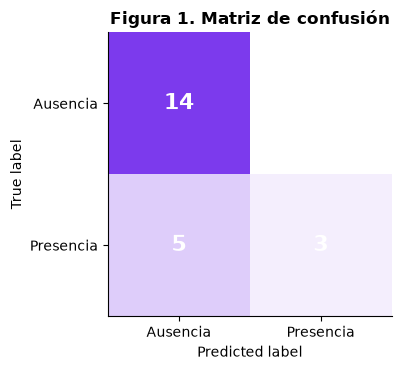

In [8]:
cm = confusion_matrix(y_test, y_pred)
cmap_cm = LinearSegmentedColormap.from_list('cm', ['#FFFFFF', VIOLETA])
fig, ax = plt.subplots(figsize=(4.5, 3.8))
ConfusionMatrixDisplay(cm, display_labels=['Ausencia','Presencia']).plot(
    ax=ax, cmap=cmap_cm, colorbar=False)
for text in ax.texts:
    text.set_fontsize(16); text.set_fontweight('bold'); text.set_color('white')
ax.set_title('Figura 1. Matriz de confusión', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Fase 3 — Explicación global y local

### 3.1 Preparación SHAP

In [9]:
X_train_t = pipeline.named_steps['preprocess'].transform(X_train)
X_test_t  = pipeline.named_steps['preprocess'].transform(X_test)
rf             = pipeline.named_steps['model']
fitted_encoder = pipeline.named_steps['preprocess'].named_transformers_['cat']

groups = numeric_features.copy()
for col, cats in zip(categorical_features, fitted_encoder.categories_):
    groups.extend([col] * len(cats))

masker    = shap.maskers.Independent(X_train_t, max_samples=len(X_train_t))
explainer = shap.TreeExplainer(rf, data=masker,
    feature_perturbation='interventional', model_output='probability')
print('Explicador SHAP listo')

Explicador SHAP listo


### 3.2 SHAP global

In [10]:
shap_test   = explainer(X_test_t)
shap_matrix = shap_test.values[:,:,1] if shap_test.values.ndim==3 else shap_test.values

grouped_shap = pd.DataFrame(index=X_test.index)
for var in X.columns:
    pos = [i for i,g in enumerate(groups) if g==var]
    grouped_shap[var] = shap_matrix[:, pos].sum(axis=1)

shap_global = (grouped_shap.abs().mean()
               .sort_values(ascending=False)
               .rename('Media_|SHAP|').to_frame())
display(shap_global.round(4))

,Media_|SHAP|
CONCEAL,0.0822
HEIGHT,0.0513
CEILING,0.0351
NEST_DIST,0.0298
BUILD_DIST,0.0187
TREE_DIST,0.0180
H_CEILING,0.0142
B_ASPECT,0.0096
B_STRUCT,0.0091
GREEN_DIST,0.0056


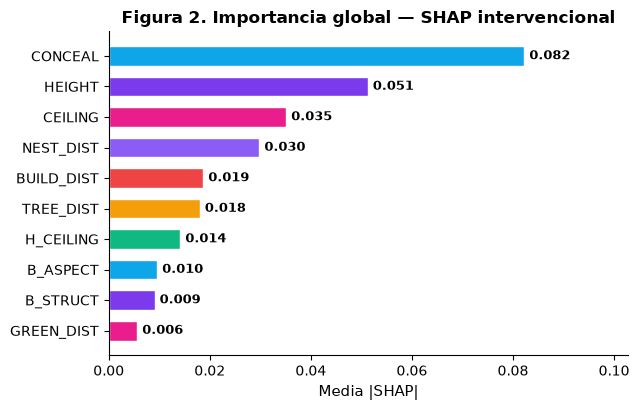

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
plot_s = shap_global.sort_values('Media_|SHAP|')
bar_colors = [PALETTE[i%len(PALETTE)] for i in range(len(plot_s))]
bars = ax.barh(plot_s.index, plot_s['Media_|SHAP|'],
               color=bar_colors, edgecolor='white', height=0.65)
for bar, val in zip(bars, plot_s['Media_|SHAP|']):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Media |SHAP|', fontsize=11)
ax.set_title('Figura 2. Importancia global — SHAP intervencional', fontsize=12, fontweight='bold')
ax.set_xlim(0, plot_s['Media_|SHAP|'].max()*1.25)
plt.tight_layout(); plt.show()

El *beeswarm* confirma el ranking de la Figura 2 y añade dirección: valores altos de CONCEAL hacia visible (C) empujan la predicción hacia ausencia, mientras que HEIGHT alto y CEILING bajo empujan hacia presencia. La Figura 2 (barra) resume magnitud; esta figura resume magnitud, dirección y dispersión por sitio, que es lo que pide un gráfico de resumen SHAP.

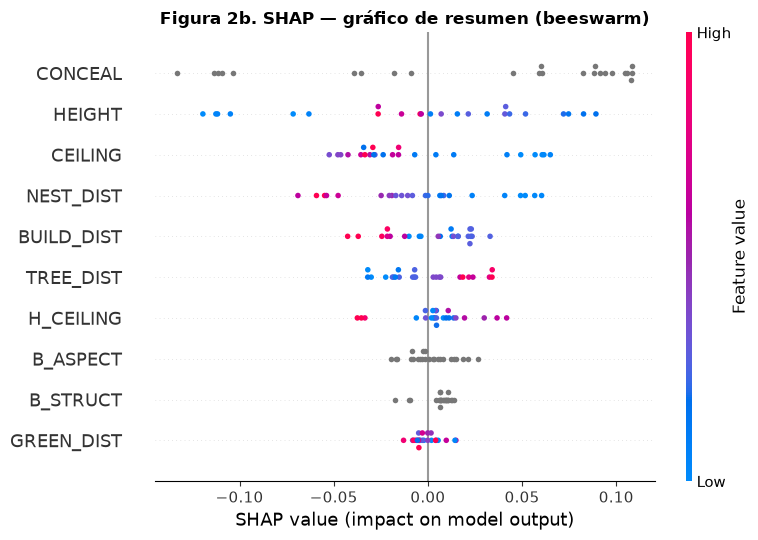

In [12]:
# Gráfico de resumen SHAP (beeswarm): añade a la Figura 2 la dirección e
# intensidad del efecto de cada variable por observación (no solo su magnitud media).
shap_grouped_test = shap.Explanation(
    values=grouped_shap.to_numpy(),
    base_values=np.zeros(len(grouped_shap)),
    data=X_test.to_numpy(),
    feature_names=list(X.columns)
)
fig = plt.figure(figsize=(7, 4.5))
shap.summary_plot(shap_grouped_test, show=False)
plt.title('Figura 2b. SHAP — gráfico de resumen (beeswarm)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.3 Importancia por permutación

In [13]:
perm = permutation_importance(pipeline, X_test, y_test,
    scoring='accuracy', n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.DataFrame({'Variable':X.columns,
    'Importancia':perm.importances_mean,
    'Desviación':perm.importances_std}).sort_values('Importancia', ascending=False)
display(perm_imp.reset_index(drop=True).round(4))

,Variable,Importancia,Desviación
0,HEIGHT,0.0333,0.0667
1,CONCEAL,0.0250,0.0425
2,CEILING,0.0250,0.0425
3,H_CEILING,0.0167,0.0204
4,B_ASPECT,0.0000,0.0000
5,B_STRUCT,0.0000,0.0000
6,BUILD_DIST,-0.0042,0.0292
7,GREEN_DIST,-0.0125,0.0191
8,NEST_DIST,-0.0208,0.0427
9,TREE_DIST,-0.0333,0.0167


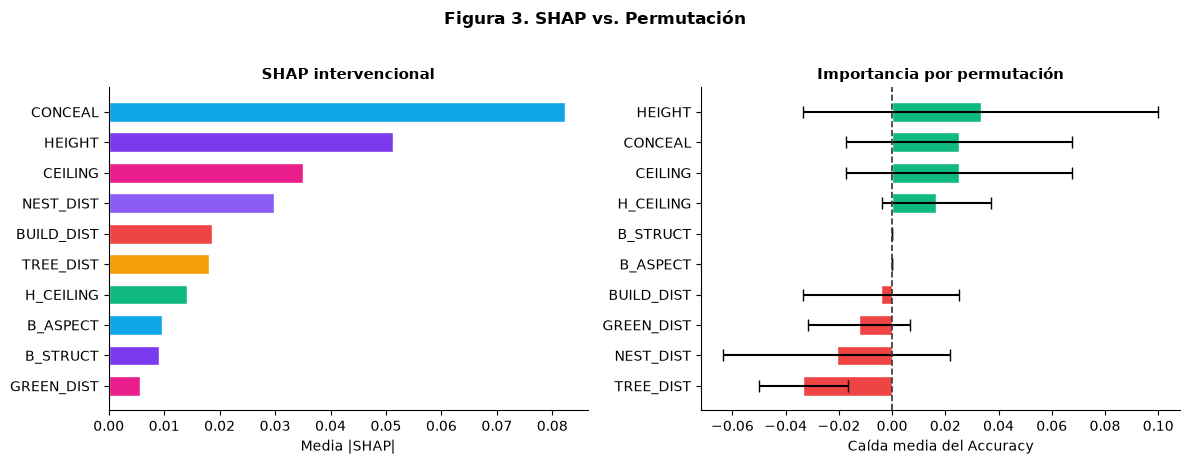

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plot_s2 = shap_global.sort_values('Media_|SHAP|')
c2 = [PALETTE[i%len(PALETTE)] for i in range(len(plot_s2))]
axes[0].barh(plot_s2.index, plot_s2['Media_|SHAP|'], color=c2, edgecolor='white', height=0.65)
axes[0].set_title('SHAP intervencional', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Media |SHAP|', fontsize=10)

plot_p = perm_imp.sort_values('Importancia')
cp = [VERDE if v>=0 else ROJO for v in plot_p['Importancia']]
axes[1].barh(plot_p['Variable'], plot_p['Importancia'],
    xerr=plot_p['Desviación'], color=cp, edgecolor='white', capsize=4, height=0.65)
axes[1].set_title('Importancia por permutación', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Caída media del Accuracy', fontsize=10)
axes[1].axvline(0, color='#333333', lw=1.2, ls='--')

fig.suptitle('Figura 3. SHAP vs. Permutación', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 3.4 SHAP local y LIME

In [15]:
test_df = X_test.copy()
test_df['y_true'] = y_test.values; test_df['y_pred'] = y_pred
sitios_ok = test_df[(test_df['y_true']==1) & (test_df['y_pred']==1)]
x_case    = X_test.loc[[sitios_ok.index[0]]].copy()
case_idx  = x_case.index[0]
case_prob = pipeline.predict_proba(x_case)[0, 1]

print(f'Sitio {case_idx} | Clase real: Presencia | P(presencia) = {case_prob:.3f}')
display(x_case.T.rename(columns={case_idx:'Valor'}))

Sitio 27 | Clase real: Presencia | P(presencia) = 0.597


,Valor
HEIGHT,315.0
CEILING,21.0
H_CEILING,72.0
TREE_DIST,8.0
BUILD_DIST,30.0
GREEN_DIST,226.5
NEST_DIST,131.4
CONCEAL,A
B_ASPECT,C
B_STRUCT,A


In [16]:
x_case_t  = pipeline.named_steps['preprocess'].transform(x_case)
shap_case = explainer(x_case_t)

if shap_case.values.ndim == 3:
    sv = shap_case.values[0,:,1]; base_case = float(shap_case.base_values[0,1])
else:
    sv = shap_case.values[0];     base_case = float(shap_case.base_values[0])

shap_case_grouped = pd.Series(index=X.columns, dtype=float)
for var in X.columns:
    pos = [i for i,g in enumerate(groups) if g==var]
    shap_case_grouped[var] = sv[pos].sum()

resultado = pd.DataFrame({'Valor':x_case.iloc[0],'SHAP':shap_case_grouped})
display(resultado.sort_values('SHAP', key=abs, ascending=False).round(4))
print(f'Base {base_case:.4f} + ΣSHAP = {base_case+shap_case_grouped.sum():.4f} ≈ {case_prob:.4f}')

,Valor,SHAP
CONCEAL,A,0.1084
HEIGHT,315.0,0.0892
CEILING,21.0,0.0616
B_ASPECT,C,-0.0163
BUILD_DIST,30.0,0.0136
B_STRUCT,A,0.0123
NEST_DIST,131.4,-0.0107
TREE_DIST,8.0,0.0068
GREEN_DIST,226.5,-0.0029
H_CEILING,72.0,-0.0012


Base 0.3365 + ΣSHAP = 0.5974 ≈ 0.5974


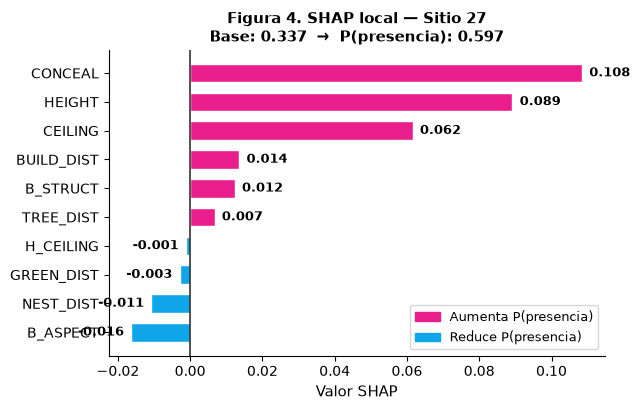

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ls = shap_case_grouped.sort_values()
bc = [POS_COLOR if v>0 else NEG_COLOR for v in ls]
bars4 = ax.barh(ls.index, ls.values, color=bc, edgecolor='white', height=0.65)
for bar, val in zip(bars4, ls.values):
    offset = 0.002 if val>=0 else -0.002
    ax.text(val+offset, bar.get_y()+bar.get_height()/2, f'{val:.3f}',
            va='center', ha='left' if val>=0 else 'right', fontsize=9, fontweight='bold')
ax.axvline(0, color='#333333', lw=1.2)
ax.set_xlabel('Valor SHAP', fontsize=11)
ax.set_title(f'Figura 4. SHAP local — Sitio {case_idx}\n'
             f'Base: {base_case:.3f}  →  P(presencia): {case_prob:.3f}',
             fontsize=11, fontweight='bold')
leg = [mpatches.Patch(color=POS_COLOR, label='Aumenta P(presencia)'),
       mpatches.Patch(color=NEG_COLOR,  label='Reduce P(presencia)')]
ax.legend(handles=leg, fontsize=9)
plt.tight_layout(); plt.show()

In [18]:
X_train_lime = X_train.copy(); x_case_lime = x_case.copy()
category_levels = {}
for col in categorical_features:
    category_levels[col] = list(X[col].cat.categories)
    X_train_lime[col] = X_train_lime[col].cat.codes
    x_case_lime[col]  = x_case_lime[col].cat.codes

categorical_indices = [X.columns.get_loc(c) for c in categorical_features]
categorical_names   = {X.columns.get_loc(c):[str(l) for l in category_levels[c]]
                       for c in categorical_features}

def predict_lime(z):
    z = pd.DataFrame(z, columns=X.columns)
    for col in categorical_features:
        lvls  = category_levels[col]
        codes = np.rint(z[col]).astype(int).clip(0, len(lvls)-1)
        z[col] = pd.Categorical([lvls[i] for i in codes], categories=lvls)
    return pipeline.predict_proba(z)

lime_explainer = LimeTabularExplainer(
    X_train_lime.to_numpy(), feature_names=X.columns.tolist(),
    class_names=['Ausencia','Presencia'], categorical_features=categorical_indices,
    categorical_names=categorical_names, mode='classification',
    discretize_continuous=False, random_state=RANDOM_STATE)

lime_exp = lime_explainer.explain_instance(
    x_case_lime.iloc[0].to_numpy(), predict_fn=predict_lime, labels=(1,), num_features=10)

lime_table = pd.DataFrame(lime_exp.as_list(label=1), columns=['Condición','Peso LIME'])
display(lime_table)
lime_pred = float(np.asarray(lime_exp.local_pred).reshape(-1)[0])
print(f'RF: {case_prob:.4f} | LIME: {lime_pred:.4f} | R²: {lime_exp.score:.4f}')

,Condición,Peso LIME
0,CONCEAL=A,0.165082
1,NEST_DIST,-0.033823
2,CEILING,-0.029995
3,TREE_DIST,0.026897
4,B_ASPECT=C,-0.020190
5,B_STRUCT=A,0.019146
6,HEIGHT,0.018969
7,BUILD_DIST,-0.008184
8,H_CEILING,-0.007182
9,GREEN_DIST,-0.002784


RF: 0.5974 | LIME: 0.3967 | R²: 0.6507


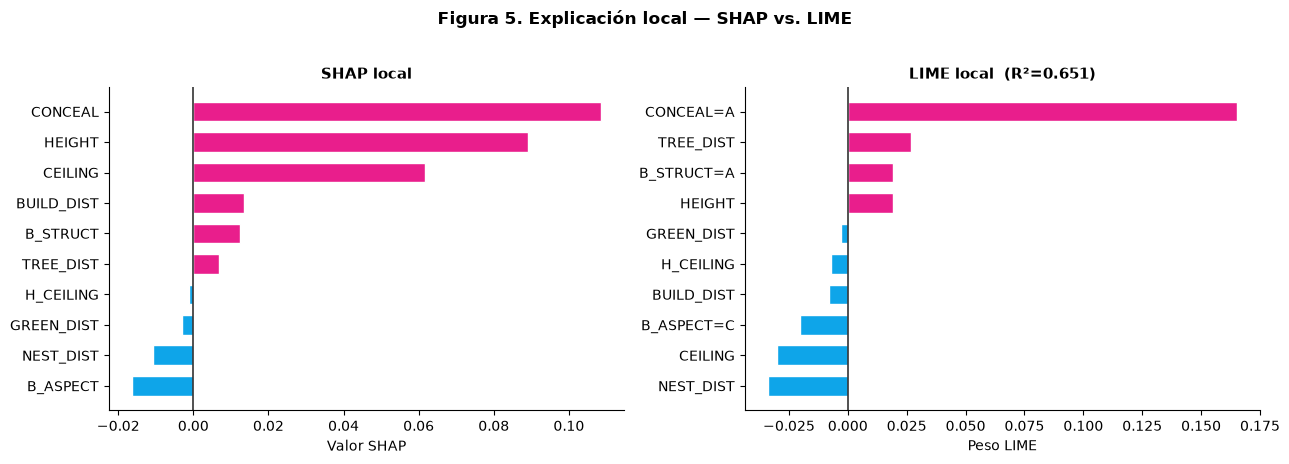

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ls2 = shap_case_grouped.sort_values()
axes[0].barh(ls2.index, ls2.values,
    color=[POS_COLOR if v>0 else NEG_COLOR for v in ls2], edgecolor='white', height=0.65)
axes[0].axvline(0, color='#333333', lw=1.2)
axes[0].set_title('SHAP local', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Valor SHAP', fontsize=10)

lt = lime_table.sort_values('Peso LIME')
axes[1].barh(lt['Condición'], lt['Peso LIME'],
    color=[POS_COLOR if v>0 else NEG_COLOR for v in lt['Peso LIME']],
    edgecolor='white', height=0.65)
axes[1].axvline(0, color='#333333', lw=1.2)
axes[1].set_title(f'LIME local  (R²={lime_exp.score:.3f})', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Peso LIME', fontsize=10)

fig.suptitle('Figura 5. Explicación local — SHAP vs. LIME', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 3.5 PDP e ICE

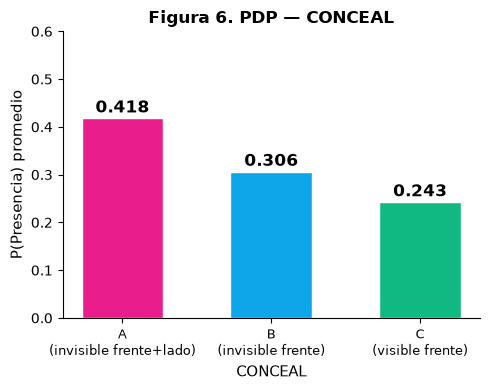

In [20]:
pdp_conceal = []
for cat in X['CONCEAL'].cat.categories:
    Xm = X_test.copy()
    Xm['CONCEAL'] = pd.Categorical([cat]*len(Xm), categories=X['CONCEAL'].cat.categories)
    pdp_conceal.append({'CONCEAL':str(cat),
                        'P(Presencia)':pipeline.predict_proba(Xm)[:,1].mean()})
pdp_conceal = pd.DataFrame(pdp_conceal)

fig, ax = plt.subplots(figsize=(5, 4))
bars6 = ax.bar(pdp_conceal['CONCEAL'], pdp_conceal['P(Presencia)'],
               color=[ROSA, AZUL, VERDE], edgecolor='white', width=0.55)
ax.set_xlabel('CONCEAL', fontsize=11); ax.set_ylabel('P(Presencia) promedio', fontsize=11)
ax.set_title('Figura 6. PDP — CONCEAL', fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.6)
ax.set_xticks([0,1,2])
ax.set_xticklabels(['A\n(invisible frente+lado)','B\n(invisible frente)','C\n(visible frente)'],fontsize=9)
for bar, row in zip(bars6, pdp_conceal.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
            f'{row._2:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

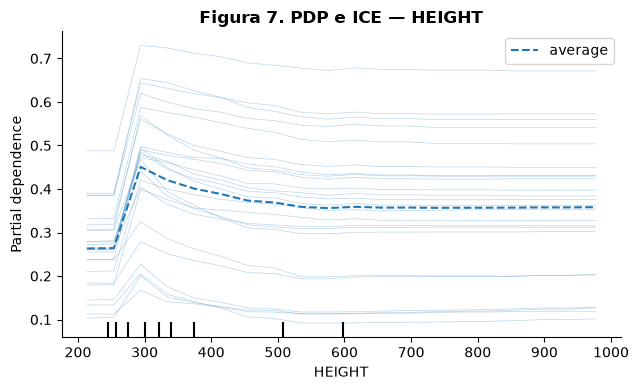

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 4))
PartialDependenceDisplay.from_estimator(pipeline, X_test, features=['HEIGHT'],
    kind='both', subsample=24, grid_resolution=20, random_state=RANDOM_STATE, ax=ax)
ax.set_title('Figura 7. PDP e ICE — HEIGHT', fontsize=12, fontweight='bold')
for line in ax.lines[:-1]: line.set_color(MORADO); line.set_alpha(0.35); line.set_linewidth(1.2)
if ax.lines: ax.lines[-1].set_color(ROSA); ax.lines[-1].set_linewidth(3)
plt.tight_layout(); plt.show()

El ALE de HEIGHT conserva la forma creciente que muestra el PDP/ICE (Figura 7), lo que indica que la dependencia de HEIGHT con otras variables numéricas no distorsiona de forma importante la relación marginal estimada por el PDP en este caso.

PyALE._ALE_generic:INFO: Continuous feature detected.


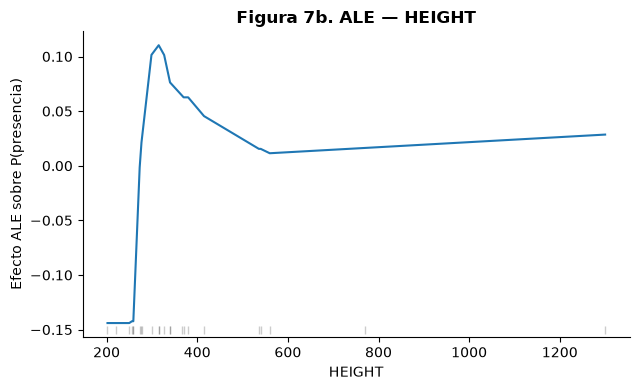

In [22]:
# ALE para HEIGHT: se justifica porque HEIGHT correlaciona con varias variables
# (CEILING, H_CEILING, BUILD_DIST, NEST_DIST — ver Figura 8 y diagnóstico de proxies),
# lo que puede sesgar el PDP al promediar sobre combinaciones poco realistas.
from PyALE import ale

class _ALEModel:
    def predict(self, Xdf):
        return pipeline.predict_proba(Xdf)[:, 1]

ale_height = ale(X=X_test.reset_index(drop=True), model=_ALEModel(),
                  feature=['HEIGHT'], grid_size=20, include_CI=False)
plt.gcf().set_size_inches(6.5, 4)
plt.title('Figura 7b. ALE — HEIGHT', fontsize=12, fontweight='bold')
plt.ylabel('Efecto ALE sobre P(presencia)')
plt.tight_layout(); plt.show()

## Fase 4 — SHAP intervencional y diagnóstico de proxies

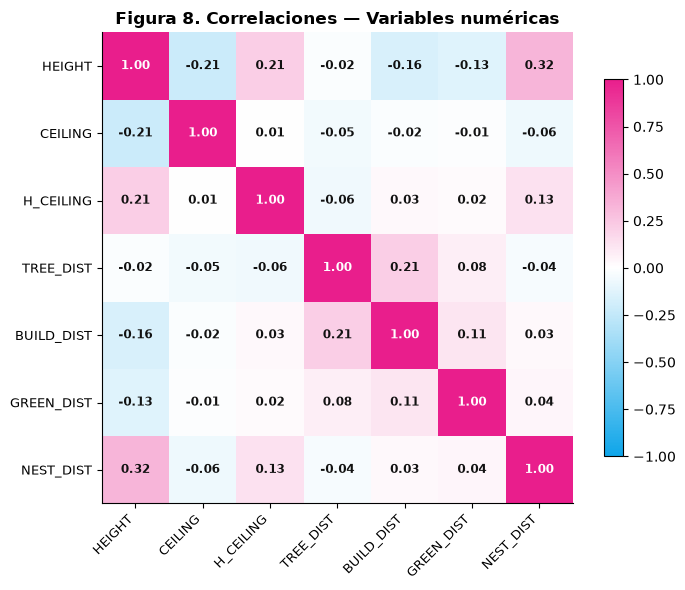

Pares con |r| > 0.15:
  HEIGHT ↔ CEILING: r = -0.213
  HEIGHT ↔ H_CEILING: r = 0.212
  HEIGHT ↔ BUILD_DIST: r = -0.164
  HEIGHT ↔ NEST_DIST: r = 0.322
  TREE_DIST ↔ BUILD_DIST: r = 0.213


In [23]:
corr = X[numeric_features].corr()
cmap_corr = LinearSegmentedColormap.from_list('corr', [AZUL,'#FFFFFF',ROSA])

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr.values, cmap=cmap_corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_features)))
ax.set_yticks(range(len(numeric_features)))
ax.set_xticklabels(numeric_features, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(numeric_features, fontsize=9)
for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        color = 'white' if abs(corr.values[i,j])>0.5 else '#111111'
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=8.5, fontweight='bold', color=color)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Figura 8. Correlaciones — Variables numéricas', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('Pares con |r| > 0.15:')
for i in range(len(numeric_features)):
    for j in range(i+1, len(numeric_features)):
        r = corr.values[i,j]
        if abs(r) > 0.15:
            print(f'  {numeric_features[i]} ↔ {numeric_features[j]}: r = {r:.3f}')

**Diagnóstico de proxies:**

El código anterior marca **5 pares** con |r| > 0.15, no solo uno:
HEIGHT↔CEILING (r=-0.21), HEIGHT↔H_CEILING (r=0.21), HEIGHT↔BUILD_DIST (r=-0.16), HEIGHT↔NEST_DIST (r=0.32) y TREE_DIST↔BUILD_DIST (r=0.21).

- **HEIGHT** concentra casi todas las correlaciones relevantes (con CEILING, H_CEILING, BUILD_DIST y NEST_DIST): puede actuar como proxy del tipo de edificio (comercial/institucional, con partes altas menos perturbadas por personas), lo que a su vez condiciona CEILING, H_CEILING y la distancia a otros nidos (NEST_DIST).
- **TREE_DIST↔BUILD_DIST (r=0.21)** es, en este conjunto, el par que juega el papel que la guía ejemplifica con TREE_DIST y GREEN_DIST: la distancia al árbol más cercano y la distancia al edificio opuesto covarían, probablemente porque ambas describen qué tan denso o abierto es el entorno inmediato del sitio. Comprobamos explícitamente el ejemplo de la guía: TREE_DIST↔GREEN_DIST solo alcanza r=0.075, es decir, en estos datos esas dos variables **no** comparten información de forma relevante, aunque sí podrían hacerlo conceptualmente.
- El SHAP intervencional rompe correlaciones entre variables *observadas*, pero no puede eliminar la confusión con variables ausentes del dataset (p. ej., disponibilidad de alimento o presión de depredadores).

## Fase 5 — Pregunta causal

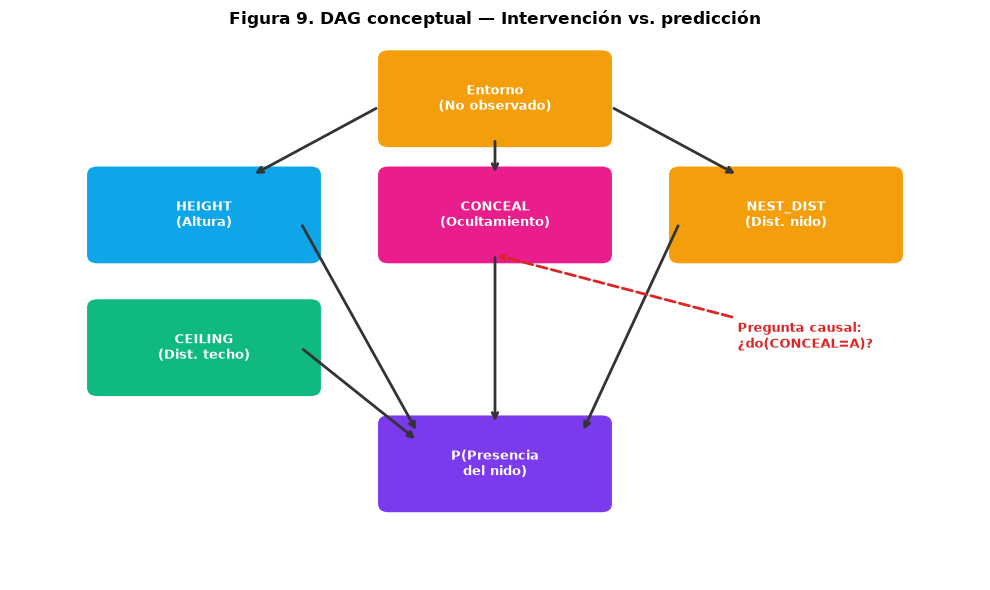

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0,10); ax.set_ylim(0,6.5); ax.axis('off')

nodos = {
    'CONCEAL\n(Ocultamiento)':(5,4.4), 'HEIGHT\n(Altura)':(2,4.4),
    'CEILING\n(Dist. techo)':(2,2.8),  'NEST_DIST\n(Dist. nido)':(8,4.4),
    'P(Presencia\ndel nido)':(5,1.4),  'Entorno\n(No observado)':(5,5.8),
}
fills = {
    'CONCEAL\n(Ocultamiento)':ROSA, 'HEIGHT\n(Altura)':AZUL,
    'CEILING\n(Dist. techo)':VERDE, 'NEST_DIST\n(Dist. nido)':NARANJA,
    'P(Presencia\ndel nido)':VIOLETA, 'Entorno\n(No observado)':NARANJA,
}
for nombre,(x,y_) in nodos.items():
    fancy = mpatches.FancyBboxPatch((x-1.1,y_-0.48),2.2,0.96,
        boxstyle='round,pad=0.12',facecolor=fills[nombre],edgecolor='white',lw=2)
    ax.add_patch(fancy)
    ax.text(x,y_,nombre,ha='center',va='center',fontsize=9,fontweight='bold',color='white')

for (x1,y1),(x2,y2) in [
    ((5,3.92),(5,1.88)),((3.0,4.3),(4.2,1.78)),((3.0,2.8),(4.2,1.68)),
    ((6.9,4.3),(5.9,1.78)),((5,5.32),(5,4.88)),((3.8,5.7),(2.5,4.88)),((6.2,5.7),(7.5,4.88))]:
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->',color='#333333',lw=2))

ax.annotate('Pregunta causal:\n¿do(CONCEAL=A)?',
    xy=(5,3.92),xytext=(7.5,2.8),fontsize=9.5,color='#DC2626',fontweight='bold',
    arrowprops=dict(arrowstyle='->',color='#DC2626',lw=2,linestyle='dashed'))
ax.set_title('Figura 9. DAG conceptual — Intervención vs. predicción',
             fontsize=12,fontweight='bold',pad=12)
plt.tight_layout(); plt.show()

**Pregunta causal central:**

> *¿Qué ocurriría con la probabilidad de anidación si se modificara activamente CONCEAL, manteniendo las demás condiciones iguales?*

Esta pregunta exige **do(CONCEAL = A)**, no P(nido | CONCEAL = A). Para responderla se necesita: (a) experimento controlado aleatorizado, (b) DAG especificado con conocimiento ecológico, o (c) ajuste por confusión con variables no observadas. Más datos observacionales no resuelven el problema.

**Limitaciones:** diseño observacional (sesgo de selección), muestra pequeña (n=96, n+=32), dependencia espacial entre sitios, variables no observadas (alimento, depredadores, perturbación histórica).